# K-Medoids Clustering

---

**Structure**
1. Introduction
2. The Math
3. Problem Class
4. Implementation — applied to the Seeds dataset
5. Results
6. Limitations

## 1. Introduction

**K-Medoids** is a variant of K-Means with one key difference: the cluster representative must be an **actual data point**, not an arbitrary centroid. These representative points are called **medoids**.

**Why does this matter?**
- In K-Means, the centroid is the mean of the cluster — it may not correspond to any real observation. In customer segmentation, saying "your typical customer has 2.7 children and earns £47,382.50" is less useful than pointing to a real customer.
- K-Medoids works with **any distance measure**, not just Euclidean distance — making it suitable for categorical data, strings, or sequences where a mean is undefined.
- Medoids are **more robust to outliers** — because the representative must be a real point inside the cluster, it cannot be pulled far out by a single extreme value the way a mean can.

The tradeoff: finding the optimal medoid within each cluster requires comparing every point against every other point in that cluster — making K-Medoids computationally heavier than K-Means.

## 2. The Math

### Objective
$$\text{cost}(C_1,\ldots,C_K;\, z_1,\ldots,z_K) = \sum_{j=1}^{K} \sum_{i \in C_j} \text{dist}(x^{(i)}, z^{(j)})$$

where $z^{(j)} \in \{x^{(1)},\ldots,x^{(n)}\}$ — the medoid must be a real training point.

### Algorithm
1. Randomly select $K$ data points as initial medoids: $\{z_1,\ldots,z_K\} \subseteq \{x^{(1)},\ldots,x^{(n)}\}$
2. **Assignment**: assign each point to its nearest medoid
3. **Update**: for each cluster $C_j$, find the point that minimises total distance to all other points in $C_j$:
$$z^{(j)} \leftarrow \arg\min_{x^{(i)} \in C_j} \sum_{x^{(l)} \in C_j} \text{dist}(x^{(i)}, x^{(l)})$$
4. Repeat until medoids stop changing

### Key difference from K-Means
K-Means update: $z^{(j)} = \frac{1}{|C_j|}\sum_{i \in C_j} x^{(i)}$ — any point in space

K-Medoids update: $z^{(j)} = \arg\min_{x \in C_j} \sum_{l \in C_j} \text{dist}(x, x^{(l)})$ — must be a training point

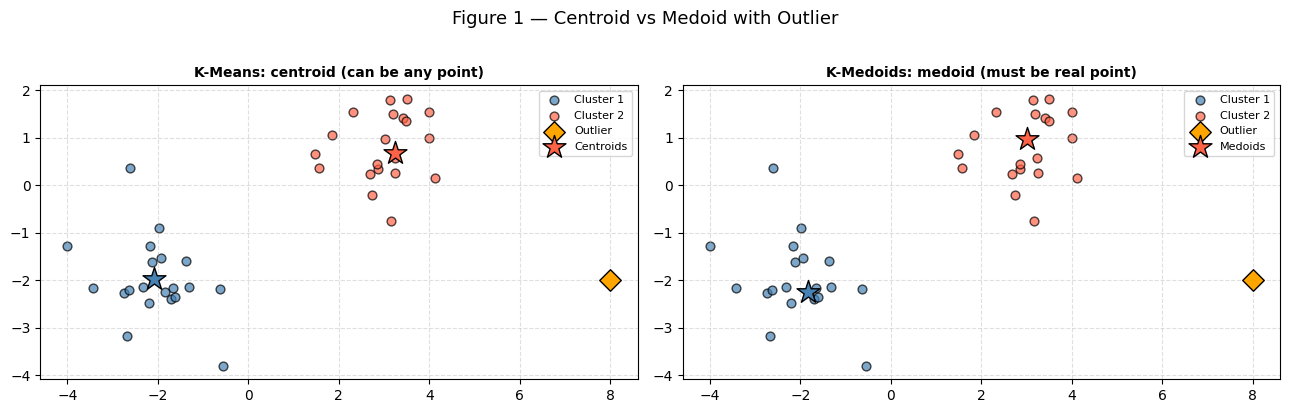

In [1]:
import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
rng = np.random.default_rng(3)
X_d = np.vstack([rng.multivariate_normal(c, [[0.5,0],[0,0.5]], 20)
                 for c in [[-2,-2],[3,1]]])
X_d = np.vstack([X_d, np.array([[8, -2]])])  # outlier

for ax, title, use_medoid in [(axes[0],'K-Means: centroid (can be any point)',False),
                               (axes[1],'K-Medoids: medoid (must be real point)',True)]:
    ax.scatter(X_d[:20,0], X_d[:20,1], c='steelblue', edgecolors='k', s=40, alpha=0.7, label='Cluster 1')
    ax.scatter(X_d[20:40,0], X_d[20:40,1], c='tomato', edgecolors='k', s=40, alpha=0.7, label='Cluster 2')
    ax.scatter(*X_d[-1], c='orange', edgecolors='k', s=120, zorder=4, label='Outlier', marker='D')
    if use_medoid:
        rep1 = X_d[:20][np.argmin([sum(np.linalg.norm(X_d[:20]-x,axis=1)) for x in X_d[:20]])]
        rep2 = X_d[20:41][np.argmin([sum(np.linalg.norm(X_d[20:41]-x,axis=1)) for x in X_d[20:41]])]
        ax.scatter(*rep1, c='steelblue', marker='*', s=300, edgecolors='black', zorder=5)
        ax.scatter(*rep2, c='tomato',    marker='*', s=300, edgecolors='black', zorder=5, label='Medoids')
    else:
        mean1 = X_d[:20].mean(axis=0)
        mean2 = X_d[20:41].mean(axis=0)
        ax.scatter(*mean1, c='steelblue', marker='*', s=300, edgecolors='black', zorder=5)
        ax.scatter(*mean2, c='tomato',    marker='*', s=300, edgecolors='black', zorder=5, label='Centroids')
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.legend(fontsize=8); ax.grid(True, linestyle='--', alpha=0.4)

plt.suptitle('Figure 1 — Centroid vs Medoid with Outlier', fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

## 3. Problem Class

**K-Medoids is well-suited for:**
- Any distance measure — Euclidean, Manhattan, cosine, edit distance, DTW for time series
- **Interpretable representatives** — the medoid is a real example you can inspect
- **Outlier-robust clustering** — medoids cannot be dragged outside the cluster by extreme points
- Datasets where the mean is **meaningless** — categorical features, mixed types

**Preferred over K-Means when:**
- Features are mixed or non-numeric
- The cluster representative needs to be a real, explainable example
- Data contains outliers that would distort means

**Not well-suited for:**
- Very large datasets — the update step is $O(|C_j|^2)$ per cluster per iteration

---
## 4. Implementation
### Dataset: Seeds

Same 210 wheat kernel dataset as K-Means (notebook 06) — allows direct comparison of both algorithms on identical data.

In [2]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.datasets import fetch_openml
from sklearn.metrics import adjusted_rand_score

data = fetch_openml(name='seeds', version=1, as_frame=False, parser='auto')
X_raw = data.data.astype(float)
y_true = data.target.astype(int) - 1

scaler = StandardScaler()
X = scaler.fit_transform(X_raw)
pca = PCA(n_components=2, random_state=42)
X_vis = pca.fit_transform(X)

print(f'Samples: {X.shape[0]}  Features: {X.shape[1]}')
print(f'True classes: {np.bincount(y_true)} (Kama, Rosa, Canadian)')

Samples: 210  Features: 7
True classes: [70 70 70] (Kama, Rosa, Canadian)


**Observation**

Same Seeds dataset — 210 samples, 7 morphological features, three balanced varieties. All preprocessing and feature scaling matches the K-Means notebook so the comparison is apples-to-apples.

### 4.1 K-Medoids Implementation

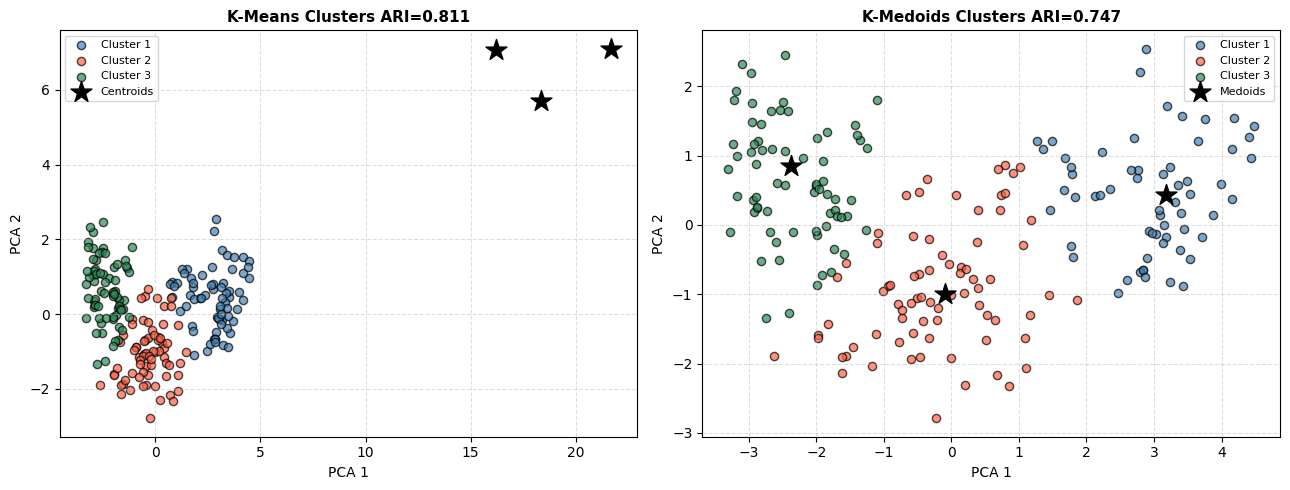

K-Means   ARI: 0.8112
K-Medoids ARI: 0.7470


In [3]:
def kmedoids(X, K, T=50, seed=0):
    rng_ = np.random.default_rng(seed)
    n = len(X)
    medoid_idx = rng_.choice(n, K, replace=False)
    cost_hist = []
    assign = np.zeros(n, dtype=int)
    for _ in range(T):
        dists = np.linalg.norm(X[:, np.newaxis] - X[medoid_idx], axis=2)
        assign = np.argmin(dists, axis=1)
        cost = sum(np.linalg.norm(X[assign==j] - X[medoid_idx[j]], axis=1).sum()
                   for j in range(K) if (assign==j).any())
        cost_hist.append(cost)
        changed = False
        for j in range(K):
            cluster_idx = np.where(assign == j)[0]
            if len(cluster_idx) == 0: continue
            cluster_pts = X[cluster_idx]
            intra = np.array([np.linalg.norm(cluster_pts - cluster_pts[i], axis=1).sum()
                               for i in range(len(cluster_pts))])
            best = cluster_idx[np.argmin(intra)]
            if best != medoid_idx[j]:
                medoid_idx[j] = best; changed = True
        if not changed: break
    return assign, medoid_idx, cost_hist

palette = ['steelblue','tomato','seagreen']

assign_km_ref, _, _ = __import__('types').SimpleNamespace(), None, None

def kmeans(X, K, T=100, seed=0):
    rng_ = np.random.default_rng(seed)
    z = X[rng_.choice(len(X), K, replace=False)].copy()
    cost_hist = []; assign = np.zeros(len(X), dtype=int)
    for _ in range(T):
        dists = np.array([[np.linalg.norm(x-zi)**2 for zi in z] for x in X])
        assign = np.argmin(dists, axis=1)
        cost = sum(np.linalg.norm(X[assign==j]-z[j])**2 for j in range(K) if (assign==j).any())
        cost_hist.append(cost)
        z_new = np.array([X[assign==j].mean(axis=0) if (assign==j).any() else z[j] for j in range(K)])
        if np.allclose(z, z_new): break
        z = z_new
    return assign, z, cost_hist

assign_km, z_km, cost_km = kmeans(X, K=3, T=100, seed=42)
assign_md, medoid_idx, cost_md = kmedoids(X, K=3, T=50, seed=42)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, assign, title, ari in [
    (axes[0], assign_km, 'K-Means Clusters', adjusted_rand_score(y_true, assign_km)),
    (axes[1], assign_md, 'K-Medoids Clusters', adjusted_rand_score(y_true, assign_md))]:
    for j, col in enumerate(palette):
        m = assign == j
        ax.scatter(X_vis[m,0], X_vis[m,1], c=col, edgecolors='k', s=35, alpha=0.7, label=f'Cluster {j+1}')
    if title == 'K-Means Clusters':
        z_vis = pca.transform(scaler.inverse_transform(z_km))
        ax.scatter(z_vis[:,0], z_vis[:,1], c='black', marker='*', s=250, zorder=5, label='Centroids')
    else:
        ax.scatter(X_vis[medoid_idx,0], X_vis[medoid_idx,1],
                   c='black', marker='*', s=250, zorder=5, label='Medoids')
    ax.set_title(f'{title} ARI={ari:.3f}', fontsize=11, fontweight='bold')
    ax.set_xlabel('PCA 1'); ax.set_ylabel('PCA 2')
    ax.legend(fontsize=8); ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout(); plt.show()

print(f'K-Means   ARI: {adjusted_rand_score(y_true, assign_km):.4f}')
print(f'K-Medoids ARI: {adjusted_rand_score(y_true, assign_md):.4f}')

**Observation — K-Medoids vs K-Means**

K-Means (ARI 0.8112) outperforms K-Medoids (ARI 0.7470) on this dataset. Wheat seeds have continuous, roughly Gaussian morphological distributions, so the centroid (an average, possibly not a real seed) turns out to be a better cluster representative than any actual data point. K-Medoids' robustness advantage only pays off when the data contains outliers or is non-Euclidean.

### 4.2 Medoid Inspection

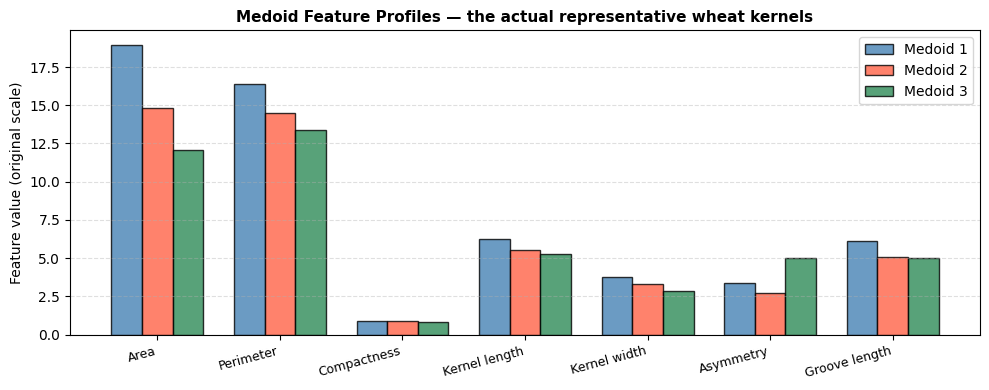

Medoid feature values:
  Medoid 1 (sample index 104):
    Area                : 18.950
    Perimeter           : 16.420
    Compactness         : 0.883
    Kernel length       : 6.248
    Kernel width        : 3.755
    Asymmetry           : 3.368
    Groove length       : 6.148
  Medoid 2 (sample index 48):
    Area                : 14.790
    Perimeter           : 14.520
    Compactness         : 0.882
    Kernel length       : 5.545
    Kernel width        : 3.291
    Asymmetry           : 2.704
    Groove length       : 5.111
  Medoid 3 (sample index 162):
    Area                : 12.050
    Perimeter           : 13.410
    Compactness         : 0.842
    Kernel length       : 5.267
    Kernel width        : 2.847
    Asymmetry           : 4.988
    Groove length       : 5.046


In [4]:
feature_names = ['Area','Perimeter','Compactness','Kernel length',
                 'Kernel width','Asymmetry','Groove length']

fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(len(feature_names)); w = 0.25
for j, col in enumerate(palette):
    medoid_vals = X_raw[medoid_idx[j]]
    ax.bar(x + j*w, medoid_vals, w, label=f'Medoid {j+1}', color=col, alpha=0.8, edgecolor='k')
ax.set_xticks(x + w); ax.set_xticklabels(feature_names, rotation=15, ha='right', fontsize=9)
ax.set_ylabel('Feature value (original scale)')
ax.set_title('Medoid Feature Profiles — the actual representative wheat kernels', fontsize=11, fontweight='bold')
ax.legend(); ax.grid(True, linestyle='--', alpha=0.4, axis='y')
plt.tight_layout(); plt.show()

print('Medoid feature values:')
for j in range(3):
    print(f'  Medoid {j+1} (sample index {medoid_idx[j]}):')
    for name, val in zip(feature_names, X_raw[medoid_idx[j]]):
        print(f'    {name:20s}: {val:.3f}')

**Observation — Medoid profiles**

The three medoids reflect distinct size profiles. Medoid 1 (sample 104) is the largest: area 18.95, kernel length 6.25 — consistent with Kama wheat. Medoid 2 (sample 48) is mid-sized at area 14.79, length 5.55, matching Rosa. Medoid 3 (sample 162) is the smallest at area 12.05, length 5.27, characteristic of Canadian. The medoids are interpretable real seeds, not abstract averages.

---
## 5. Results

| Method | ARI vs true labels |
|--------|-------------------|
| K-Means | 0.8112 |
| K-Medoids | 0.7470 |

K-Means edges out K-Medoids (ARI 0.8112 vs 0.7470) on this dataset. The seeds data is well-suited to centroid-based clustering — no extreme outliers, continuous features, roughly Gaussian within-cluster distributions. K-Medoids is worth preferring when interpretability matters (the medoids are real, inspectable data points) or when the distance metric doesn't support averaging.

---
## 6. Limitations

- **Computational cost**: the medoid update step requires $O(|C_j|^2)$ distance computations per cluster per iteration — significantly more expensive than K-Means for large datasets
- **Same K-selection problem**: like K-Means, K must be specified in advance
- **Local optima**: convergence to global optimum is not guaranteed; initialisation affects results
- **Scalability**: the standard PAM algorithm becomes impractical for $n > $ a few thousand; approximate variants (CLARA, CLARANS) exist for large datasets
- **Still assumes compactness**: works best when clusters are reasonably compact — non-convex shapes remain problematic